# Explainable Chest X-ray Classification — Provided Dataset
AIMS-DTU Research Intern 2026 · Explainable Computer Vision

Runs the full pipeline on **the dataset provided by AIMS-DTU**

## 1. Getting the project code into Colab
Uploaded `excv-xray.zip` via the Files panel, then ran this.

In [2]:
import os, glob
if not os.path.exists('config.py'):
    z = glob.glob('/content/excv-xray.zip')
    assert z, 'Upload excv-xray.zip via the Files panel first.'
    os.system(f'unzip -o -q {z[0]} -d /content')
    hit = glob.glob('/content/**/config.py', recursive=True)[0]
    os.chdir(os.path.dirname(hit))
print('working dir:', os.getcwd())

working dir: /content/excv-xray


## 2. Installing dependencies

In [3]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 118.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 28.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 40.0 MB/s eta 0:00:00


## 3. Unzipping the PROVIDED dataset
uploded the dataset files previously, unzipping them here.

In [4]:
import os, glob
os.makedirs('/content/provided', exist_ok=True)

# find the provided dataset zip in /content (first match), or set it manually
zips = [z for z in glob.glob('/content/*.zip')
        if 'radiography' not in z.lower() and 'excv' not in z.lower() and 'outputs' not in z.lower()]
print('candidate dataset zip(s):', zips)
assert zips, 'Provided dataset zip not found in /content — upload it or fix the path.'
!unzip -o -q "{zips[0]}" -d /content/provided

# show what came out, with per-folder image counts
for dp,_,fn in os.walk('/content/provided'):
    imgs=[f for f in fn if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if imgs: print(f'{len(imgs):7d}  {dp.replace("/content/provided","")}')

candidate dataset zip(s): ['/content/COVID_19_dataset.zip']
    200  /__MACOSX/COVID_19_dataset/val/Viral Pneumonia
    200  /__MACOSX/COVID_19_dataset/val/Normal
    200  /__MACOSX/COVID_19_dataset/val/COVID
   1000  /__MACOSX/COVID_19_dataset/train/Viral Pneumonia
   1000  /__MACOSX/COVID_19_dataset/train/Normal
   1000  /__MACOSX/COVID_19_dataset/train/COVID
    145  /__MACOSX/COVID_19_dataset/test/Viral Pneumonia
    145  /__MACOSX/COVID_19_dataset/test/Normal
    145  /__MACOSX/COVID_19_dataset/test/COVID
    200  /COVID_19_dataset/val/Viral Pneumonia
    200  /COVID_19_dataset/val/Normal
    200  /COVID_19_dataset/val/COVID
   1000  /COVID_19_dataset/train/Viral Pneumonia
   1000  /COVID_19_dataset/train/Normal
   1000  /COVID_19_dataset/train/COVID
    145  /COVID_19_dataset/test/Viral Pneumonia
    145  /COVID_19_dataset/test/Normal
    145  /COVID_19_dataset/test/COVID


## 4. Pointing the pipeline at the provided dataset


In [14]:
import re, pathlib
root = '/content/provided/COVID_19_dataset'
cfg = pathlib.Path('config.py').read_text()
cfg = re.sub(r'data_root: str = ".*?"', f'data_root: str = "{root}"', cfg)
pathlib.Path('config.py').write_text(cfg)

# quick detection preview (no training yet)
from importlib import reload
import config; reload(config)
from src import data
info = data.discover(root, config.Config())
print('classes:', info['classes'])
print('layout :', info['layout'])
print('images : train=%d val=%d test=%d' % (len(info['train']),len(info['val']),len(info['test'])))

classes: ['COVID', 'Normal', 'Viral Pneumonia']
layout : pre-split
images : train=3000 val=600 test=435


## 5. Train

In [15]:
!python run.py train

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
DATASET DETECTED
  root   : /content/provided/COVID_19_dataset
  layout : pre-split
  classes: ['COVID', 'Normal', 'Viral Pneumonia']
  images : train=3000  val=600  test=435
  per-class (train): {'COVID': 1000, 'Normal': 1000, 'Viral Pneumonia': 1000}
model.safetensors: 100% 346M/346M [00:02<00:00, 121MB/s]
epoch 1/8:   0% 0/94 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of 

## 6. Classification metrics (accuracy / precision / recall / F1)

In [16]:
!python run.py classify

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
DATASET DETECTED
  root   : /content/provided/COVID_19_dataset
  layout : pre-split
  classes: ['COVID', 'Normal', 'Viral Pneumonia']
  images : train=3000  val=600  test=435
  per-class (train): {'COVID': 1000, 'Normal': 1000, 'Viral Pneumonia': 1000}
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. 

## 7. Saliency maps

In [17]:
!python run.py explain

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
DATASET DETECTED
  root   : /content/provided/COVID_19_dataset
  layout : pre-split
  classes: ['COVID', 'Normal', 'Viral Pneumonia']
  images : train=3000  val=600  test=435
  per-class (train): {'COVID': 1000, 'Normal': 1000, 'Viral Pneumonia': 1000}
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. 

## 8. XAI evaluation — Insertion/Deletion, Entropy, AOPC

In [18]:
!python run.py xai-eval

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
DATASET DETECTED
  root   : /content/provided/COVID_19_dataset
  layout : pre-split
  classes: ['COVID', 'Normal', 'Viral Pneumonia']
  images : train=3000  val=600  test=435
  per-class (train): {'COVID': 1000, 'Normal': 1000, 'Viral Pneumonia': 1000}
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. 

## 9. Bonus — baseline ranking-stability

In [19]:
!python run.py bonus

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
DATASET DETECTED
  root   : /content/provided/COVID_19_dataset
  layout : pre-split
  classes: ['COVID', 'Normal', 'Viral Pneumonia']
  images : train=3000  val=600  test=435
  per-class (train): {'COVID': 1000, 'Normal': 1000, 'Viral Pneumonia': 1000}
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. 

## 10. View key figures

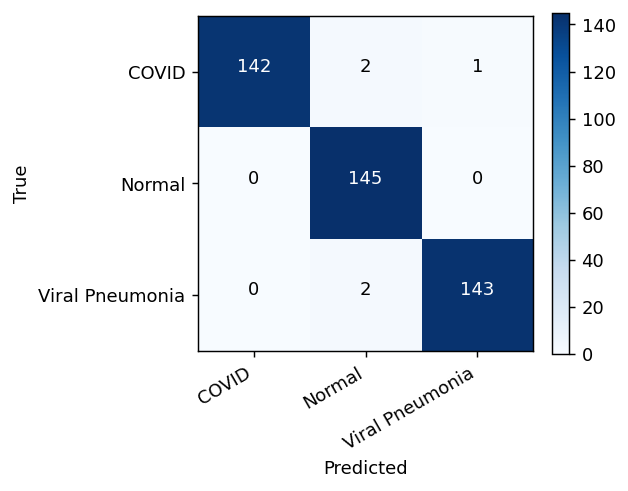

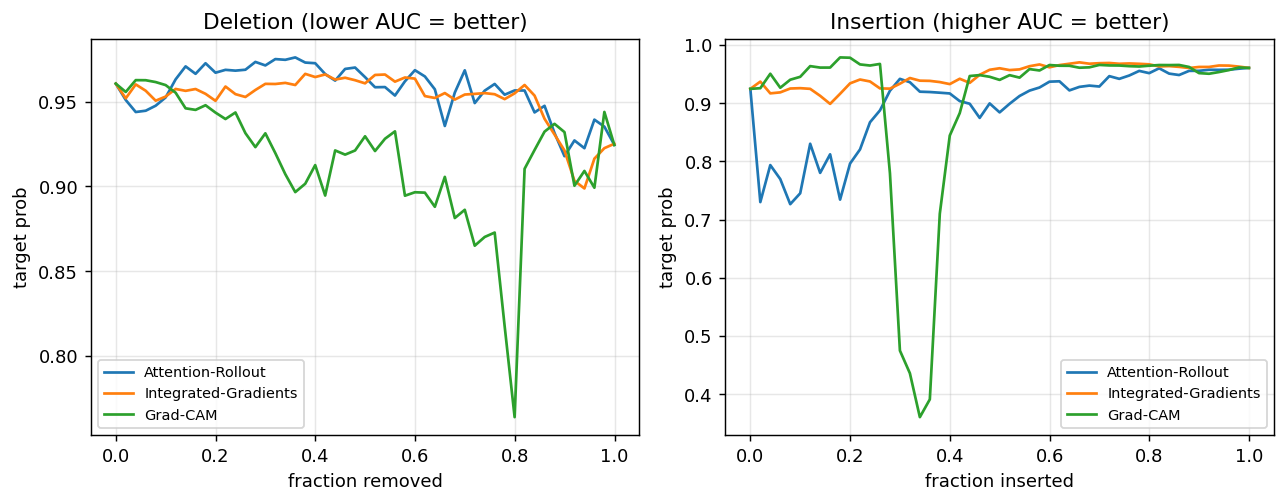

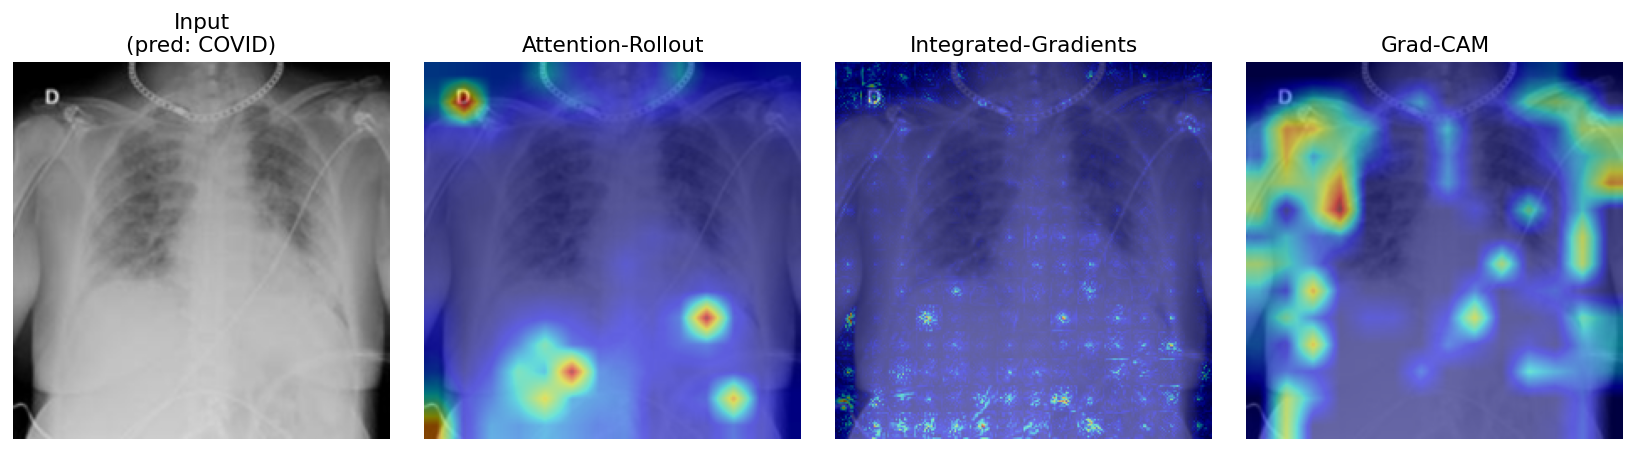

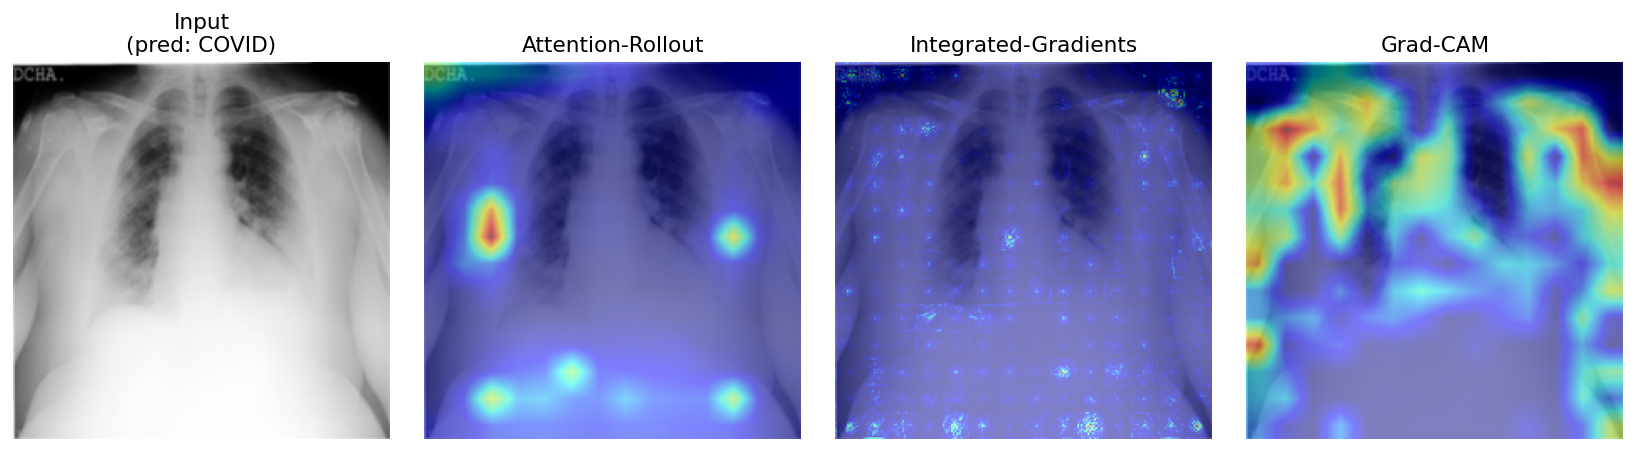

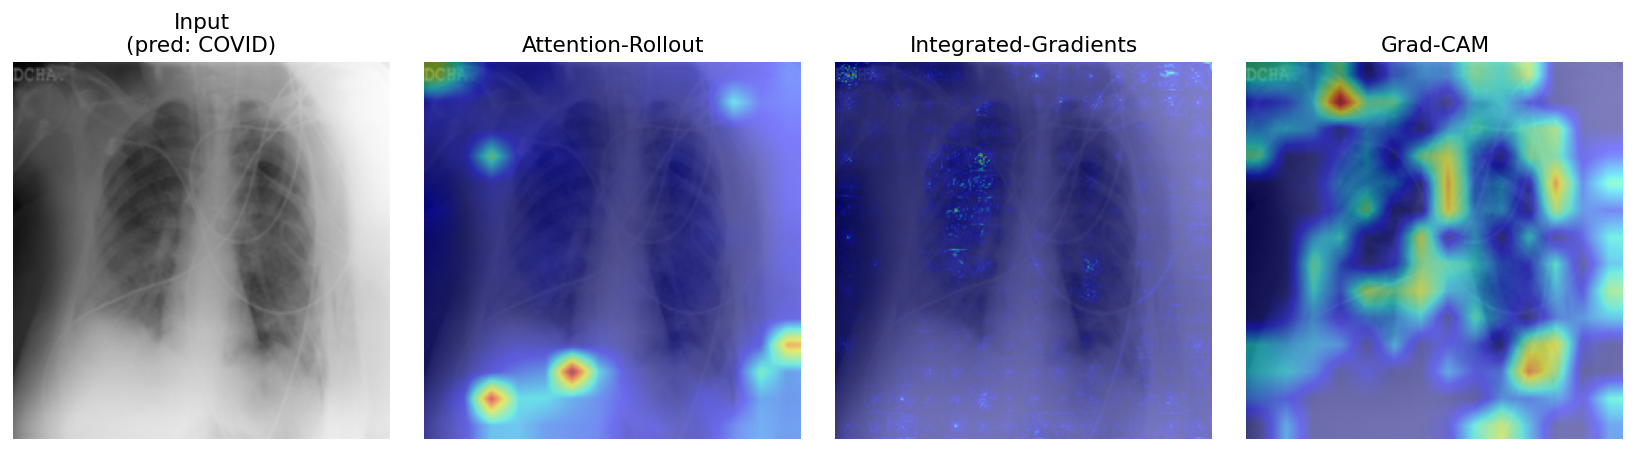

In [20]:
from IPython.display import Image, display
import glob, os
for f in ['outputs/confusion_matrix.png','outputs/insertion_deletion_curves.png']:
    if os.path.exists(f): display(Image(f))
for f in sorted(glob.glob('outputs/saliency/*.png'))[:3]:
    display(Image(f))

## 11. Download outputs (weights + figures + JSON) for Google Drive

In [21]:
!zip -qr outputs.zip outputs
from google.colab import files
files.download('outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>